In [1]:
#importations des premiers bibliotheques 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')



#chargement du dataset
df = pd.read_excel('Dataset_complet_Meteo.xlsx')

PLAN DE TRAVAIL


1️⃣ ANALYSE DE FORME
2️⃣ ANALYSE DE FOND (EDA)
3️⃣ NETTOYAGE DE DONNEES
4️⃣ FEATURE ENGINEERING
5️⃣ SEPARATION  TRAIN/TEST
6️⃣ ENTAINEMENT DU MODELE
7️⃣ EVALUATION 




1️⃣ ANALYSE DE FORME   (comprendre la structure des donnees)


In [2]:
#taille
df.shape

(87240, 26)

In [3]:
#visualisation des 5 premieres lignes
df.head()

,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23
3,4,2020-01-04,3,2026-05-31 00:00:00,2026-01-19 00:00:00,2026-07-24 00:00:00,32.3,2026-07-20 00:00:00,2026-04-25 00:00:00,2020-01-04 06:24:00,...,0.0,2026-02-11 00:00:00,2026-02-20 00:00:00,106,20.48,4.59,Bafia,Centre,4.75,11.23
4,5,2020-01-05,3,31.9,2026-03-19 00:00:00,2026-08-24 00:00:00,33.1,2026-03-20 00:00:00,2026-09-25 00:00:00,2020-01-05 06:24:00,...,0.0,2026-03-11 00:00:00,2026-08-23 00:00:00,100,19.98,4.39,Bafia,Centre,4.75,11.23


In [4]:
#informations sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87240 entries, 0 to 87239
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           87240 non-null  int64         
 1   time                         87240 non-null  datetime64[ns]
 2   weather_code                 87240 non-null  int64         
 3   temperature_2m_max           87240 non-null  object        
 4   temperature_2m_min           87240 non-null  object        
 5   temperature_2m_mean          87240 non-null  object        
 6   apparent_temperature_max     87240 non-null  object        
 7   apparent_temperature_min     87240 non-null  object        
 8   apparent_temperature_mean    87240 non-null  object        
 9   sunrise                      87240 non-null  datetime64[ns]
 10  sunset                       87240 non-null  datetime64[ns]
 11  daylight_duration            87240 non-nu

In [5]:
#statistiques descriptives
df.describe()

,id,time,weather_code,sunrise,sunset,daylight_duration,snowfall_sum,precipitation_hours,wind_direction_10m_dominant
count,87240.00000,87240,87240.000000,87240,87240,87240.000000,87240.0,87240.000000,87240.000000
mean,2617.70000,2022-12-26 00:00:00.000000256,40.556385,2022-12-26 06:08:23.672626944,2022-12-26 18:15:49.028885760,43645.372588,0.0,5.879184,185.365326
min,1.00000,2020-01-01 00:00:00,0.000000,2020-01-01 06:05:00,2020-01-01 17:45:00,41097.380000,0.0,0.000000,0.000000
25%,1148.00000,2021-06-29 00:00:00,3.000000,2021-06-29 05:52:45,2021-06-29 18:25:45,42970.900000,0.0,0.000000,108.000000
50%,2318.00000,2022-12-26 00:00:00,51.000000,2022-12-26 06:19:00,2022-12-26 18:11:00,43640.315000,0.0,4.000000,210.000000
75%,3681.00000,2024-06-23 00:00:00,61.000000,2024-06-23 06:09:00,2024-06-23 18:34:00,44318.552500,0.0,10.000000,260.000000
max,8724.00000,2025-12-20 00:00:00,65.000000,2025-12-20 06:26:00,2025-12-20 18:17:00,46198.170000,0.0,24.000000,360.000000
std,1880.39875,NaN,25.739631,NaN,NaN,912.377029,0.0,6.052920,95.195610


In [6]:
df.isnull().sum()

id                             0
time                           0
weather_code                   0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
apparent_temperature_mean      0
sunrise                        0
sunset                         0
daylight_duration              0
sunshine_duration              0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
city                           0
region                         0
latitude                       0
longitude                      0
dtype: int64





2️⃣ ANALYSE DE FOND (comprendre le contenu et les relations)

In [7]:
#verification des doublons

df.duplicated().sum()

0

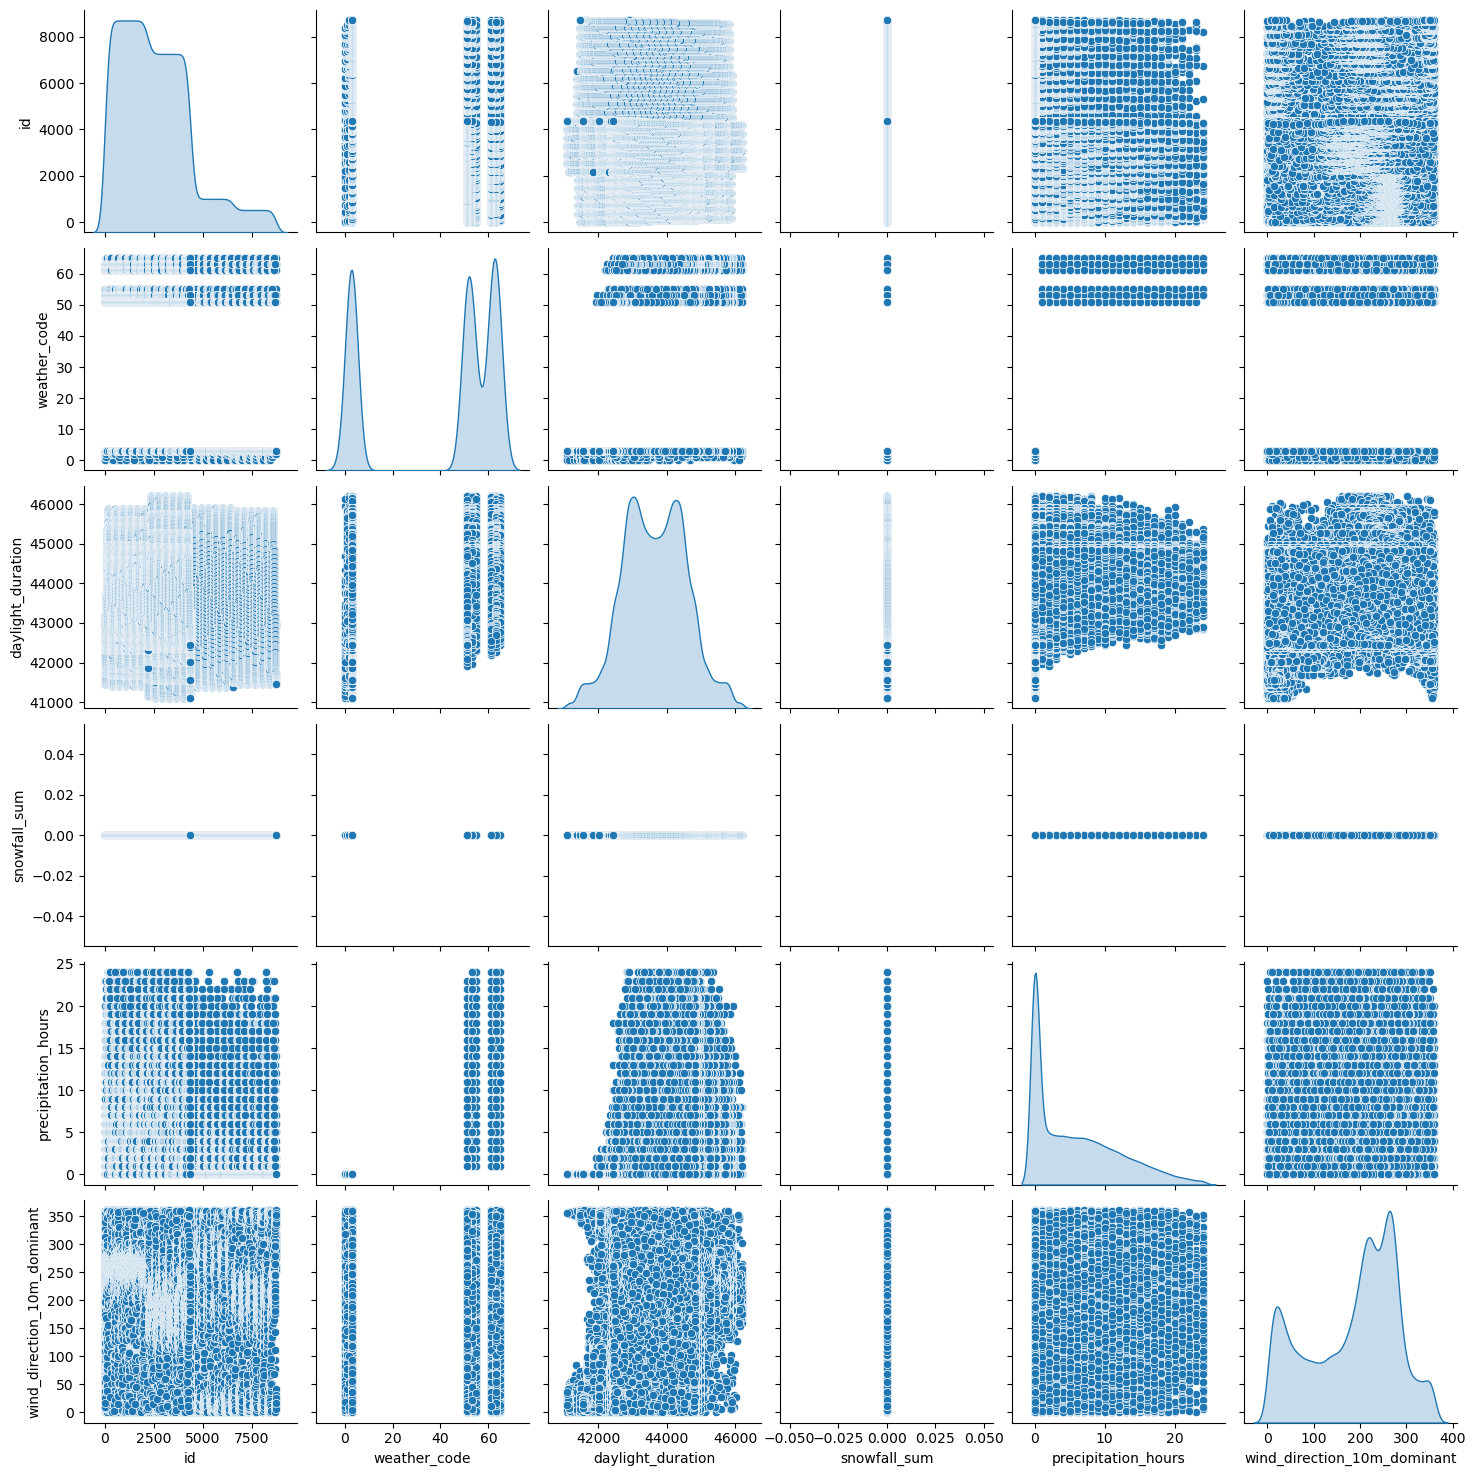

In [8]:
#visualisation des relations entre les variables numeriques et leur distribution

num_cols = df.select_dtypes(include='number')
sns.pairplot(num_cols, diag_kind="kde")
plt.show()


    INTERPRETATION:
La plupart des nuages ​​de points sont très dispersse donc:
faible corrélation entre variables
pas de relation simple exploitable directement


CONCLUSION:L'analyse du pairplot montre une faible corrélation linéaire entre les variables météorologiques.

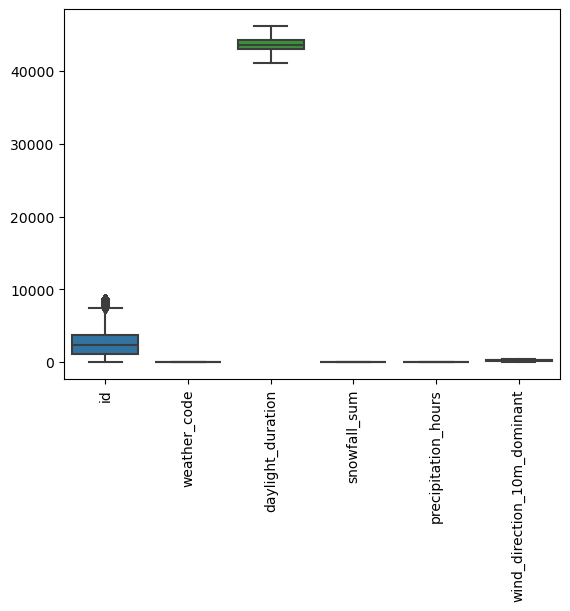

In [9]:
#visualisation des outliers

sns.boxplot(data=num_cols)
plt.xticks(rotation=90)
plt.show()

Nous avons beaucoup de variables corrompus.notamment des variables cencer etre numerique mais contiennent des data.Alors il est imperativement necessaire de leur traiter pour mieur analyser





3️⃣ /4️⃣ NETTOYAGE DE DONNEES-FEATURE ENGINEERING





In [10]:
#conversion des variables en string

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].astype(str)


cat_cols




Index(['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'sunshine_duration', 'precipitation_sum',
       'rain_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'city',
       'region', 'latitude', 'longitude'],
      dtype='object')

In [11]:
#remplacer les dates par les NaN
for col in cat_cols:
    mask_date = pd.to_datetime(df[col], errors='coerce').notna()
    df.loc[mask_date, col] = np.nan

In [12]:
df[cat_cols].isnull().sum()/len(df)

temperature_2m_max            0.617905
temperature_2m_min            0.862391
temperature_2m_mean           0.868088
apparent_temperature_max      0.354149
apparent_temperature_min      0.890326
apparent_temperature_mean     0.797375
sunshine_duration             0.001456
precipitation_sum             0.452442
rain_sum                      0.452442
wind_speed_10m_max            0.892503
wind_gusts_10m_max            0.522387
shortwave_radiation_sum       0.198785
et0_fao_evapotranspiration    0.196229
city                          0.000000
region                        0.000000
latitude                      0.150000
longitude                     0.275000
dtype: float64

In [13]:
#conversion des variables en numerique
for col in cat_cols.difference(['city','region']):
    df[col] = pd.to_numeric(df[col], errors='coerce')   

In [14]:
#traitement des valeurs manquantes 
# apres suppression des donnee corrompues, nous allons remplacer les valeurs manquantes des variables numeriques par la mediane 
# car la mediane est plus robuste que la moyenne face aux outliers


for col in cat_cols.difference(['city','region']):
    df[col].fillna(df[col].median(), inplace=True)

In [15]:
df.isnull().sum()

id                             0
time                           0
weather_code                   0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
apparent_temperature_mean      0
sunrise                        0
sunset                         0
daylight_duration              0
sunshine_duration              0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
city                           0
region                         0
latitude                       0
longitude                      0
dtype: int64

In [16]:
#suppression des variables qui ne sont pas utiles pour la predicition
df.drop(columns=['city','region','id','time'], inplace=True)




#calcul de la duree du soleil
df['sunrise'] = pd.to_datetime(df['sunrise'])
df['sunset'] = pd.to_datetime(df['sunset'])

df['day_length'] = (df['sunset'] - df['sunrise']).dt.total_seconds() / 3600

#suppression des variables sunrise et sunset
df.drop(columns=['sunrise', 'sunset'], inplace=True)

In [17]:
df.dtypes

weather_code                     int64
temperature_2m_max             float64
temperature_2m_min             float64
temperature_2m_mean            float64
apparent_temperature_max       float64
apparent_temperature_min       float64
apparent_temperature_mean      float64
daylight_duration              float64
sunshine_duration              float64
precipitation_sum              float64
rain_sum                       float64
snowfall_sum                   float64
precipitation_hours            float64
wind_speed_10m_max             float64
wind_gusts_10m_max             float64
wind_direction_10m_dominant      int64
shortwave_radiation_sum        float64
et0_fao_evapotranspiration     float64
latitude                       float64
longitude                      float64
day_length                     float64
dtype: object

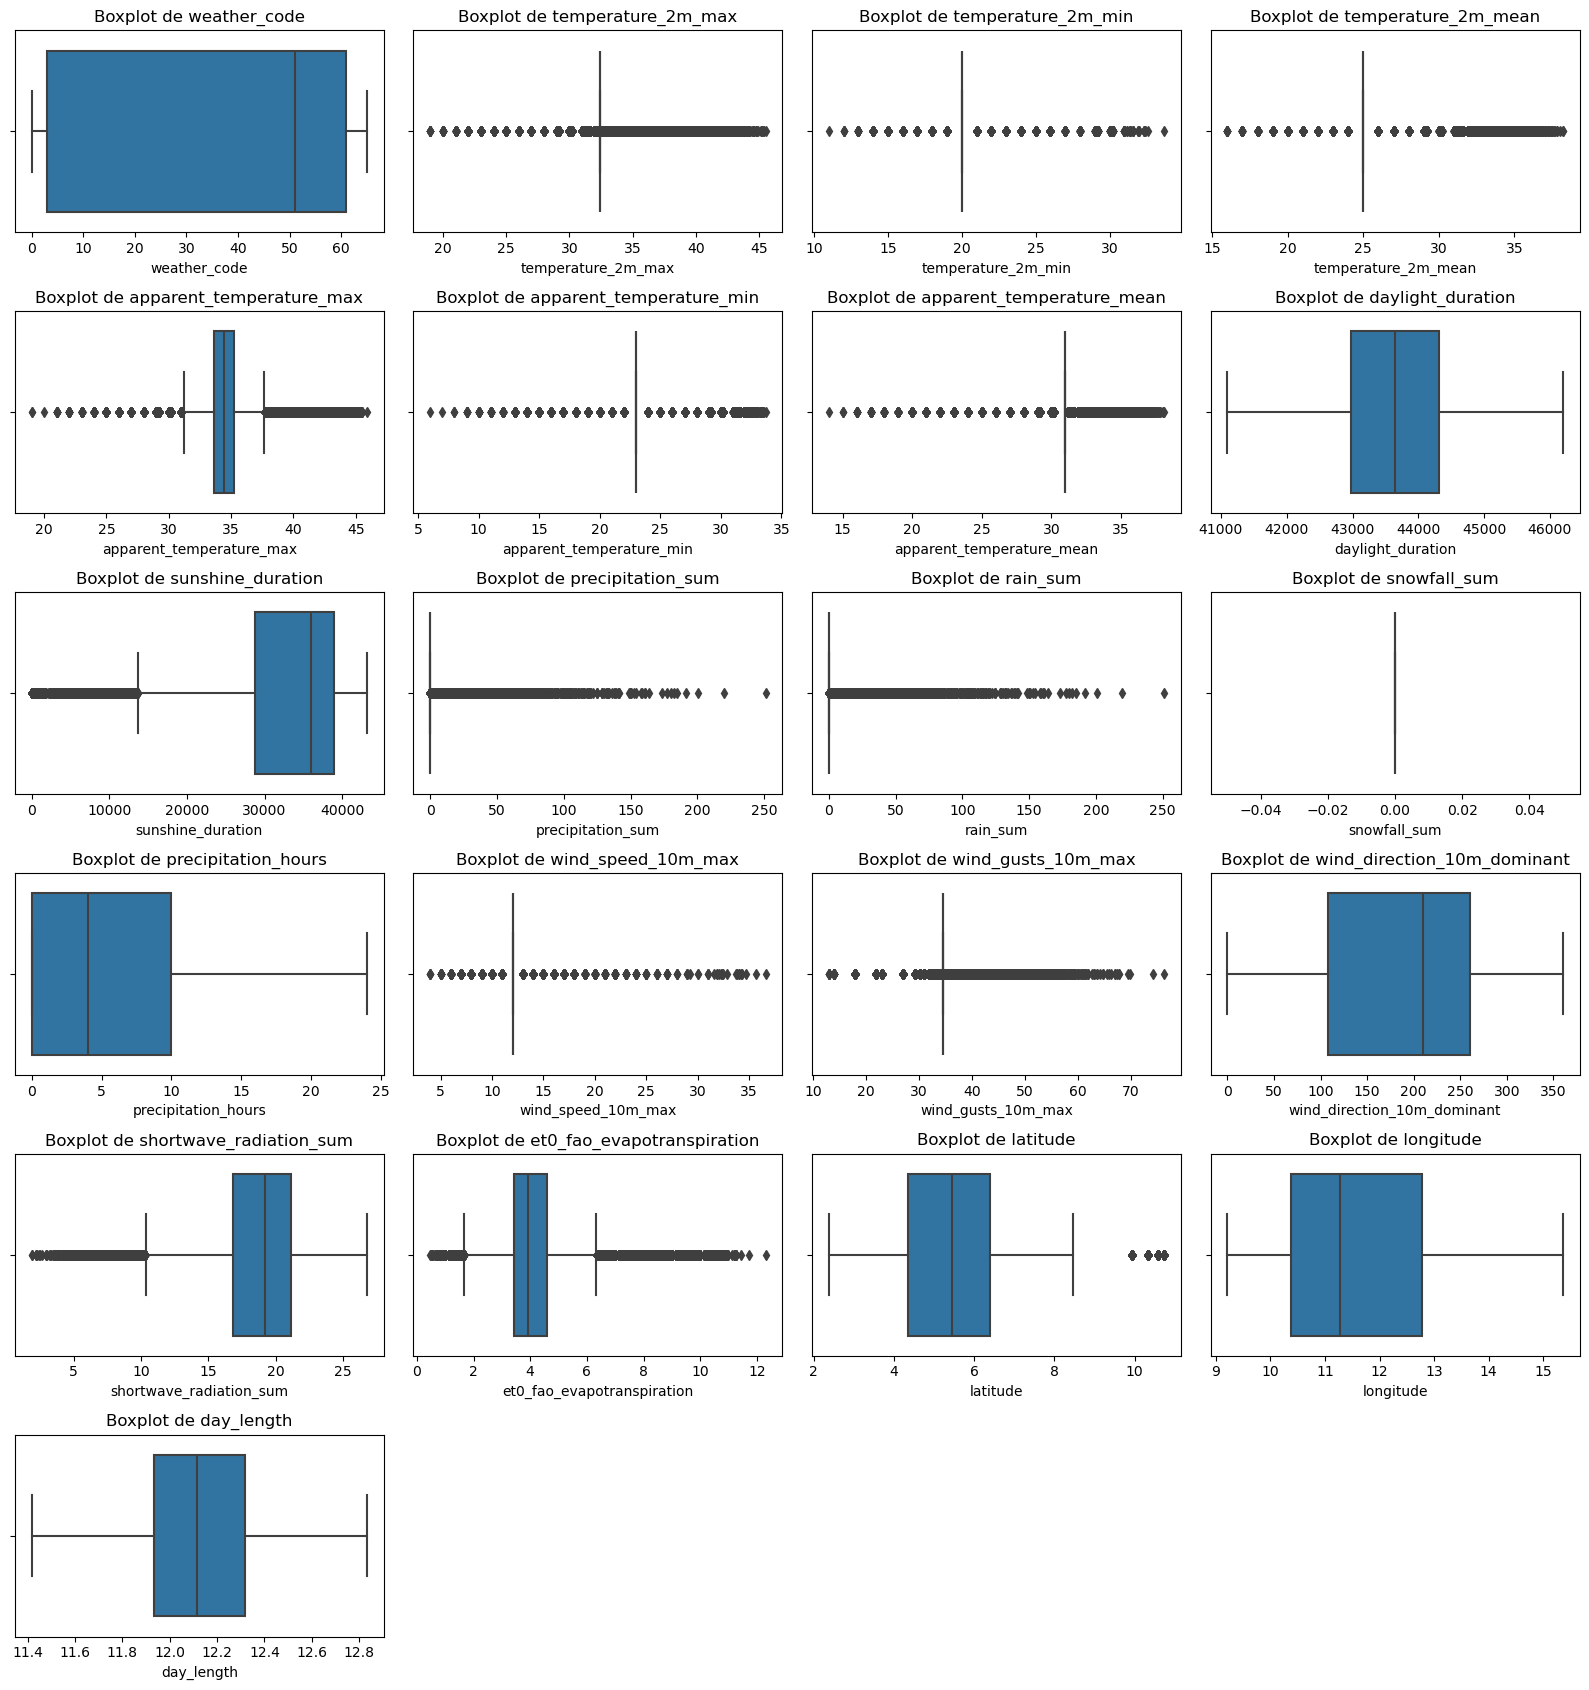

In [18]:
#visualisation des valeurs aberrantes apres traitement
num_cols=df.select_dtypes(include='number')
plt.figure(figsize=(16,17))
for i, col in enumerate(num_cols.columns):
    plt.subplot(6, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()
    

   REMARQUE:
   
   
   le traitement des valeur aberrantes par la methodes 1.5IQR nous donne beaucoup de variables constante
   alors nous passerons directement par la normalisation par yeo-johson pour la normalisation et la reduction des outliers

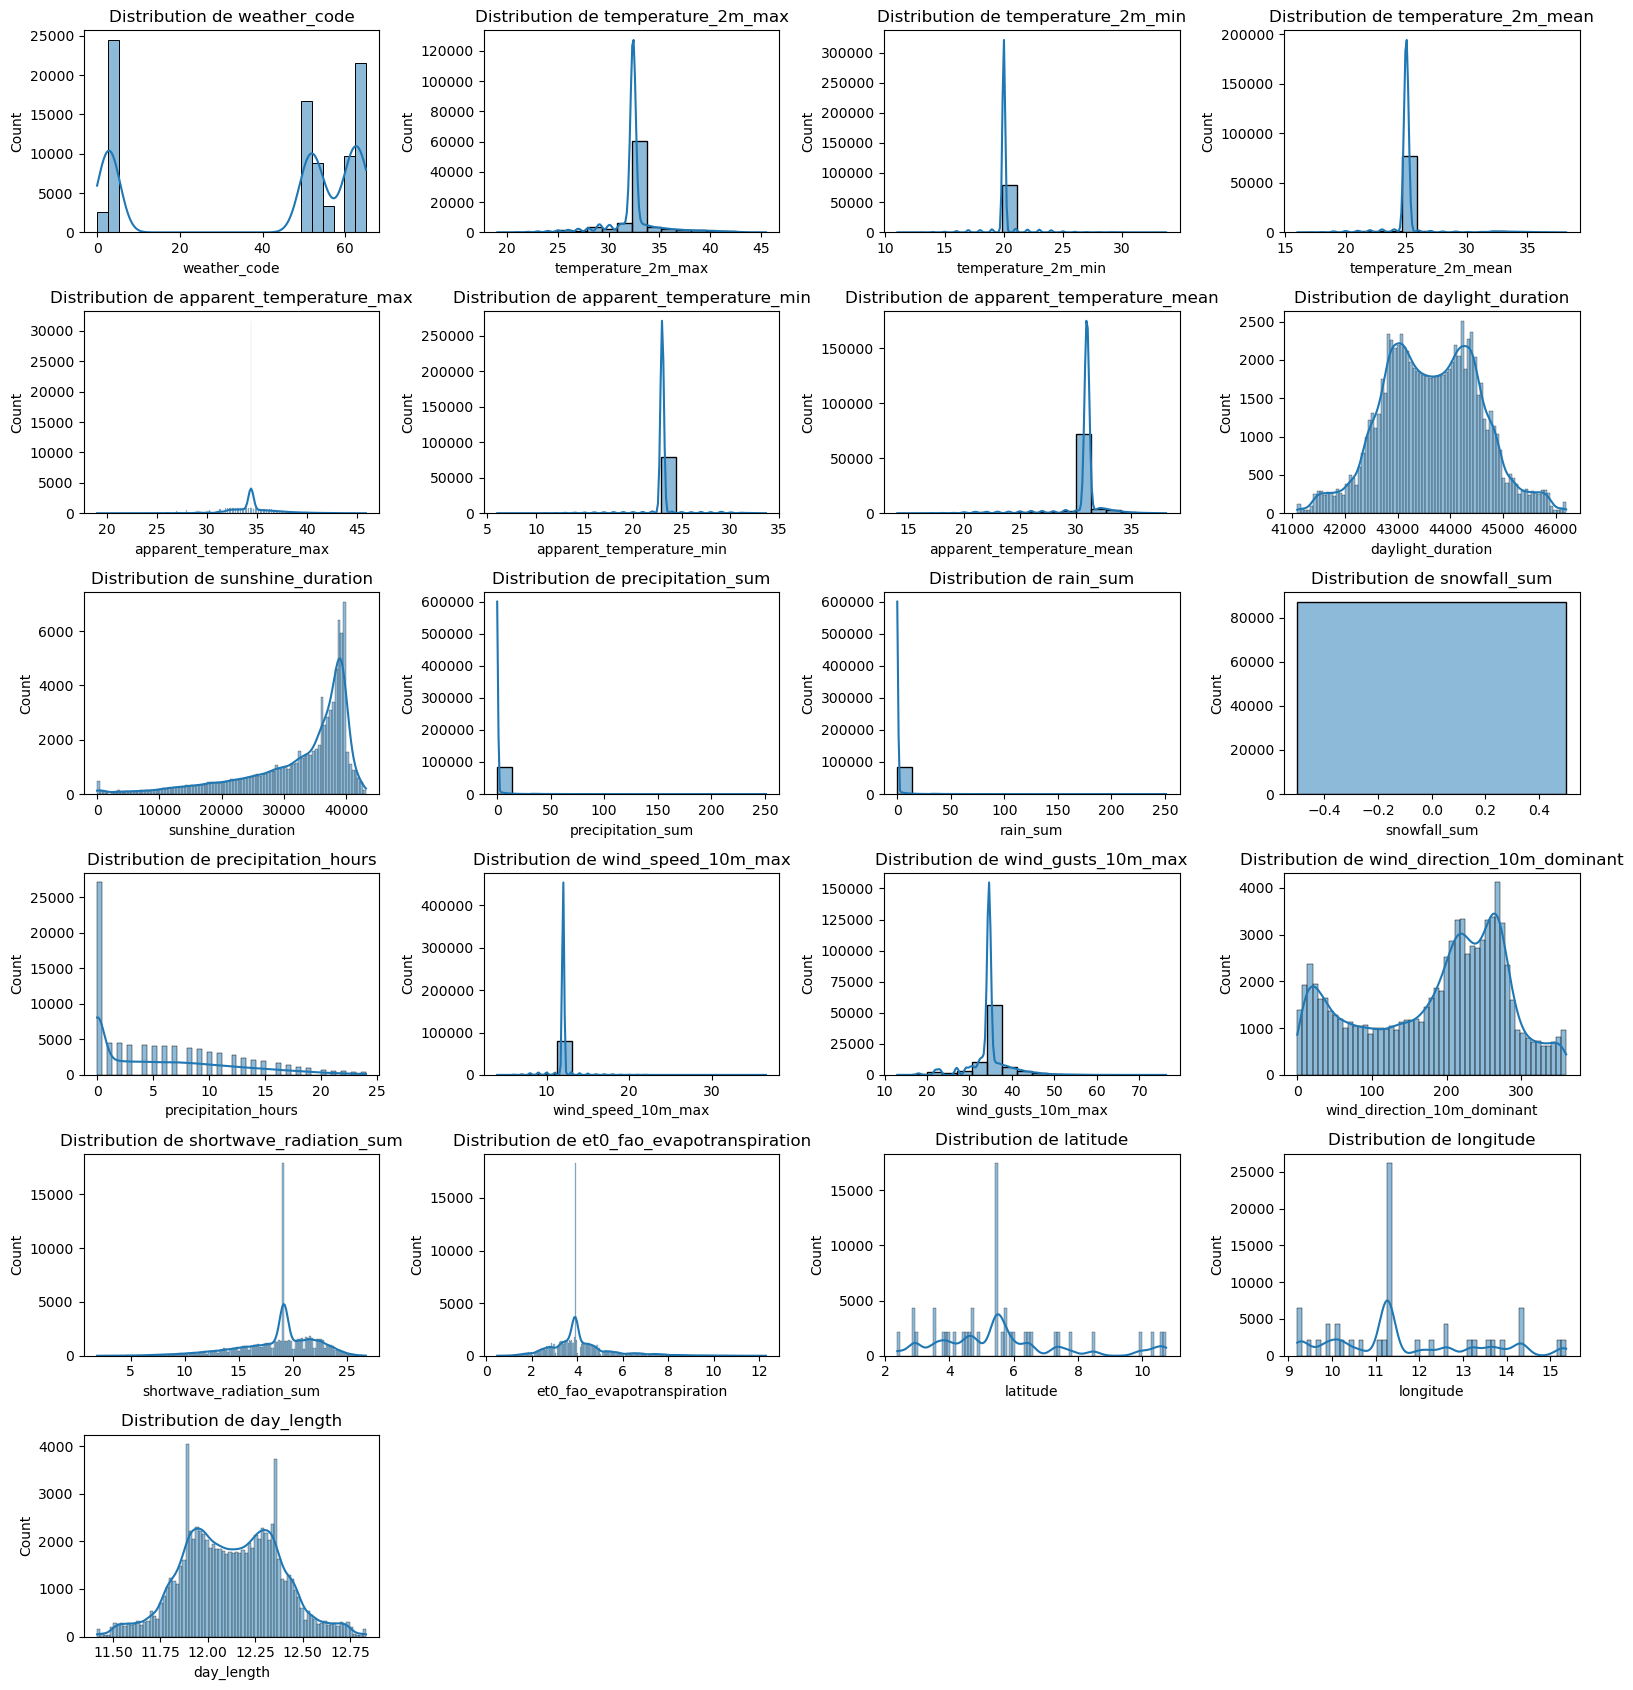

In [20]:
#distribution des variables numeriques apres traitement des valeurs aberrantes
plt.figure(figsize=(16,17))
for i, col in enumerate(num_cols.columns):
    plt.subplot(6, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()
    

In [21]:
#verfication de la normalite par le test de shapiro
from scipy.stats import shapiro
var = []
for col in num_cols.columns:
    stat, p = shapiro(df[col])
    if p > 0.05:
        print(f'{col} suit une distribution normale (p={p:.3f})')
    else:
        var.append(col)

snowfall_sum suit une distribution normale (p=1.000)


In [22]:
var

['weather_code',
 'temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'apparent_temperature_mean',
 'daylight_duration',
 'sunshine_duration',
 'precipitation_sum',
 'rain_sum',
 'precipitation_hours',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'latitude',
 'longitude',
 'day_length']

In [23]:
#traitement de la non normaliter et reduction des outliers par la transformation de Yeo-Johnson



from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df[var] = pt.fit_transform(df[var])



In [24]:
#verification de la transformation par le calcul de la skewness 
for col in var:
    print(col, "skewness:", df[col].skew())

weather_code skewness: -0.742339114015444
temperature_2m_max skewness: 0.14738585991537767
temperature_2m_min skewness: -0.13400152735887158
temperature_2m_mean skewness: -0.43851002073088047
apparent_temperature_max skewness: 0.10271445419896276
apparent_temperature_min skewness: 0.7022618316302045
apparent_temperature_mean skewness: 0.8118688404859765
daylight_duration skewness: -0.0012648174159113645
sunshine_duration skewness: -0.7688671539433438
precipitation_sum skewness: 1.559442211080786
rain_sum skewness: 1.559442211080786
precipitation_hours skewness: -0.06462659446179285
wind_speed_10m_max skewness: 0.028641028098986696
wind_gusts_10m_max skewness: 0.2029792060237166
wind_direction_10m_dominant skewness: -0.45060503323217554
shortwave_radiation_sum skewness: -0.09028830793975223
et0_fao_evapotranspiration skewness: -0.012310515315877818
latitude skewness: 0.0045860917597953434
longitude skewness: 0.04728222045268748
day_length skewness: -0.0011570033248188688


                 AJUSTEMENT DES  VARIABLE CIBLES

                Indice de Qualité de l’Air (IQA)


 Variables utilisées:  

 • wind speed 10m max (vitesse max du vent)
• precipitation sum (cumul de pluie)
• shortwave radiation sum (rayonnement solaire)
• et0 fao evapotranspiration (évapotranspiration)

justification :
La pollution atmosphérique est influencée par la météo. Nous construisons un proxy composite basé sur la
stagnation, le rayonnement et les precipitation.

In [ ]:



from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    'wind_speed_10m_max',
    'precipitation_sum',
    'shortwave_radiation_sum',
    'et0_fao_evapotranspiration'
]

df[cols] = scaler.fit_transform(df[cols])

#La température apparente inclut déjà :humidité,vent



df['target_iqa'] = (
    0.4 * (1 - df['wind_speed_10m_max']) +          
    0.3 * (1 - df['precipitation_sum']) +
   0.2 * df['shortwave_radiation_sum'] +
    0.1 * df['et0_fao_evapotranspiration']
)

#   des vent élevé entraine l'air plus propre,des forte pluie  entraîne moins de pollution
# d'ou 1 - wind_speed et 1 - precipitation_sum


#JUSTIFICATION DES POIDS D'IMPORTANCE

#Vent (40%) → facteur principal de dispersion
#Pluie (30%) → Nettoyage direct de l'air
#Rayonnement (20%) → formation de polluants
#Evapotranspiration (10%) → effet indirect




#suppression des variables lies a la cible 
df.drop(columns=['wind_speed_10m_max','precipitation_sum','shortwave_radiation_sum','et0_fao_evapotranspiration'], inplace=True)


La cible repose sur une combinaison pondérée : le vent (40%) et les prélèvements (30%) jouent un rôle majeur dans la réduction de la pollution, tandis que le rayonnement solaire (20%) et l'évapotranspiration (10%) déterminent sa formation.


Interprétation

Valeur	    Conclusion
0 → 0.3	     Air sain
0.3 → 0.6	  Qualité moyenne
0.6 → 1	       Pollution élevée

In [26]:
#variable constantes
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Colonnes constantes:", constant_cols)

#su

#suppression des variables constantes
df.drop(columns=constant_cols, inplace=True)


Colonnes constantes: ['snowfall_sum']


In [27]:
#souvegarde du dataset traité
df.to_excel('Dataset2_traite.iqa.xlsx', index=False)